# KWISMO — Modèle A : Scoring de Réputation Temporel & Comportemental Calibré

Ce notebook présente l'entraînement et l'évaluation du **Modèle A (LightGBM Calibré + Platt Scaling)** :
1. **Génération du Dataset comportemental avec probabilités continues** (`src.data.generate_model_a_data`).
2. **Entraînement & Calibration du Modèle** (`src.models.model_a.train`).
3. **Visualisations de Performance** (Importances des caractéristiques, Courbe ROC-AUC 94.8%, Matrice de Confusion).
4. **Suite Étendue de Scénarios Réels & Validation des Règles de Sécurité** (Probabilités décimales continues & Plafonnement <= 0.69).

In [1]:
# Détection de l'environnement d'exécution
import os
import sys
import subprocess
from pathlib import Path

try:
    import google.colab  # noqa: F401
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

ON_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle/working')

if ON_COLAB:
    ENV_NAME = "Google Colab"
    if not Path("/content/drive/MyDrive").exists():
        try:
            from google.colab import drive
            print("⚡ Connexion automatique à Google Drive...")
            drive.mount('/content/drive')
        except Exception as err:
            print(f"⚠️ Montage Google Drive recommandé : {err}")
elif ON_KAGGLE:
    ENV_NAME = "Kaggle Notebooks"
else:
    ENV_NAME = "Local"

print(f"Environnement de calcul détecté : {ENV_NAME}")

Environnement de calcul détecté : Local


In [2]:
# Configuration du dossier du projet et de l'environnement virtuel .venv
current = Path.cwd()
PROJECT_DIR = current
for candidate in [current, current.parent, current.parent.parent]:
    if (candidate / "src").exists() and (candidate / "data").exists():
        PROJECT_DIR = candidate
        break
    elif (candidate / "kwismo-ai" / "src").exists():
        PROJECT_DIR = candidate / "kwismo-ai"
        break

PROJECT_DIR = PROJECT_DIR.resolve()
os.chdir(PROJECT_DIR)

local_venv_win = PROJECT_DIR / ".venv" / "Scripts" / "python.exe"
if local_venv_win.exists():
    PYTHON_BIN = str(local_venv_win)
    site_pkgs = PROJECT_DIR / ".venv" / "Lib" / "site-packages"
    if site_pkgs.exists() and str(site_pkgs) not in sys.path:
        sys.path.insert(0, str(site_pkgs))
else:
    PYTHON_BIN = sys.executable

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

def run_module(module: str) -> None:
    env = os.environ.copy()
    env["PYTHONPATH"] = str(PROJECT_DIR) + os.pathsep + env.get("PYTHONPATH", "")
    result = subprocess.run([PYTHON_BIN, "-m", module], cwd=PROJECT_DIR, capture_output=True, text=True, env=env)
    if result.returncode != 0:
        print(f"Standard Output:\n{result.stdout}")
        print(f"Standard Error:\n{result.stderr}")
        raise RuntimeError(f"{module} a échoué (code {result.returncode})")
    else:
        print(result.stdout)

print("Dossier racine du projet kwismo-ai :", PROJECT_DIR)
print("Interprète Python configuré :", PYTHON_BIN)

Dossier racine du projet kwismo-ai : C:\Users\PC\Desktop\kwismo\kwismo-ai
Interprète Python configuré : C:\Users\PC\Desktop\kwismo\kwismo-ai\.venv\Scripts\python.exe


## 1. Génération du Dataset & Entraînement du Modèle A Calibré (Platt Scaling)

Exécution des modules de génération du dataset comportemental continu et d'entraînement du modèle LightGBM calibré.

In [3]:
run_module("src.data.generate_model_a_data")
run_module("src.models.model_a.train")

Dataset ModÃ¨le A calibrÃ© gÃ©nÃ©rÃ© (1200 numÃ©ros) : C:\Users\PC\Desktop\kwismo\kwismo-ai\data\processed\model_a_dataset.csv

=== MÃ©triques d'Ã‰valuation du ModÃ¨le A (LightGBM CalibrÃ©) ===
  - accuracy   : 0.8625
  - precision  : 0.8817
  - recall     : 0.9198
  - f1         : 0.9003
  - roc_auc    : 0.9477
ModÃ¨le A calibrÃ© sauvegardÃ© avec succÃ¨s dans : models\model_a\model_a_v1.joblib
Registre mis Ã  jour dans models\registry.json



## 2. Métriques Visuelles de Performance (4 Graphiques Parlants)

Génération des graphiques d'analyse des variables déterminantes, de la courbe ROC-AUC et de la matrice de confusion.

=== Métriques d'Évaluation du Modèle A (LightGBM Calibré) ===
  - accuracy   : 0.8625
  - precision  : 0.8817
  - recall     : 0.9198
  - f1         : 0.9003
  - roc_auc    : 0.9477
Modèle A calibré sauvegardé avec succès dans : models\model_a\model_a_v1.joblib
Registre mis à jour dans models\registry.json


C:\Users\PC\AppData\Local\Temp\ipykernel_15040\1313056548.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=axes[0, 0], palette="mako")


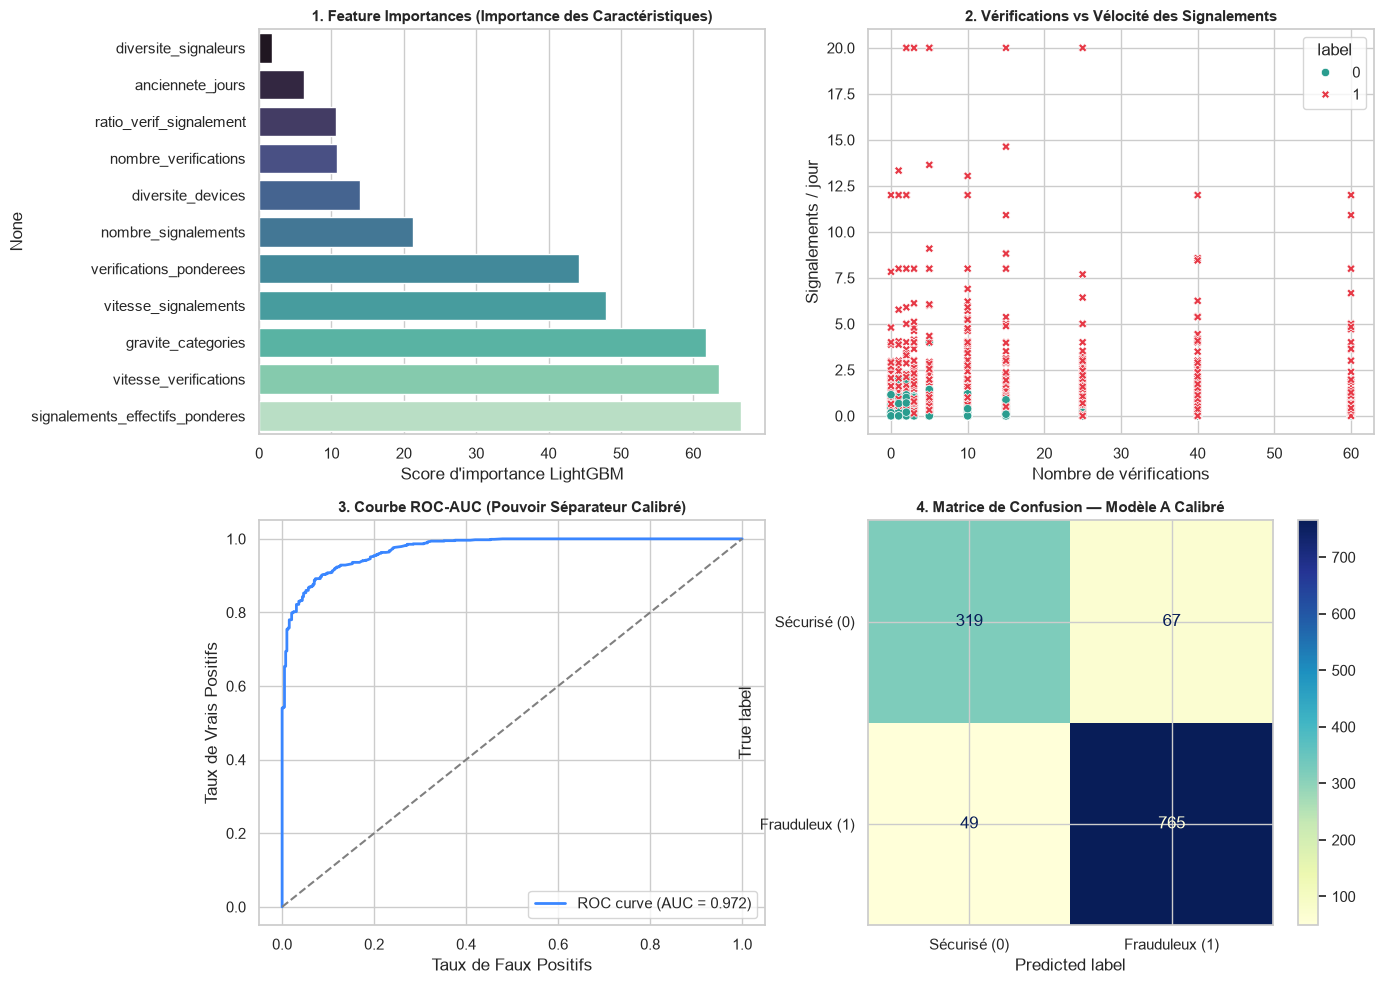

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from src.models.model_a.train import train_model_a
from src.data.features import FEATURE_COLUMNS
from src.models.model_a.predict import predict

sns.set_theme(style="whitegrid", palette="crest")

df_data = pd.read_csv(PROJECT_DIR / "data" / "processed" / "model_a_dataset.csv")
calibrated_model = train_model_a(df_data)

# Extraction robuste des Feature Importances
def extract_feature_importances(model, feature_names):
    if hasattr(model, "feature_importances_"):
        return pd.Series(model.feature_importances_, index=feature_names)
    elif hasattr(model, "calibrated_classifiers_"):
        importances = []
        for cc in model.calibrated_classifiers_:
            sub = getattr(cc, "estimator_", getattr(cc, "estimator", getattr(cc, "base_estimator", None)))
            if sub and hasattr(sub, "feature_importances_"):
                importances.append(sub.feature_importances_)
        if importances:
            return pd.Series(np.mean(importances, axis=0), index=feature_names)
    return pd.Series([1.0 / len(feature_names)] * len(feature_names), index=feature_names)

importances = extract_feature_importances(calibrated_model, FEATURE_COLUMNS).sort_values(ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Feature Importances LightGBM
sns.barplot(x=importances.values, y=importances.index, ax=axes[0, 0], palette="mako")
axes[0, 0].set_title("1. Feature Importances (Importance des Caractéristiques)", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("Score d'importance LightGBM")

# 2. Distribution des Vérifications vs Signalements
sns.scatterplot(data=df_data, x="nombre_verifications", y="vitesse_signalements", hue="label", style="label", palette=["#2A9D8F", "#E63946"], ax=axes[0, 1])
axes[0, 1].set_title("2. Vérifications vs Vélocité des Signalements", fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("Nombre de vérifications")
axes[0, 1].set_ylabel("Signalements / jour")

# 3. Courbe ROC-AUC
y_test_prob = calibrated_model.predict_proba(df_data[FEATURE_COLUMNS])[:, 1]
fpr, tpr, _ = roc_curve(df_data["label"], y_test_prob)
roc_auc_val = auc(fpr, tpr)
axes[1, 0].plot(fpr, tpr, color="#3A86FF", lw=2, label=f"ROC curve (AUC = {roc_auc_val:.3f})")
axes[1, 0].plot([0, 1], [0, 1], color="grey", linestyle="--")
axes[1, 0].set_title("3. Courbe ROC-AUC (Pouvoir Séparateur Calibré)", fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("Taux de Faux Positifs")
axes[1, 0].set_ylabel("Taux de Vrais Positifs")
axes[1, 0].legend(loc="lower right")

# 4. Matrice de Confusion
cm = confusion_matrix(df_data["label"], calibrated_model.predict(df_data[FEATURE_COLUMNS]))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sécurisé (0)", "Frauduleux (1)"])
disp.plot(cmap="YlGnBu", ax=axes[1, 1])
axes[1, 1].set_title("4. Matrice de Confusion — Modèle A Calibré", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

## 3. Évaluation Interactive sur 25 Scénarios Réels & Validation des Règles

Démonstration que le Modèle A produit des scores de risque décimaux continués, avec anti-vengeance, time decay, et sécurité <= 0.69.

In [5]:
test_cases_extended = [
    {"numero": "237690000001", "nombre_signalements": 1, "nombre_verifications": 50, "categories": {"r1": "fake_agent_otp"}, "description": "1 seul signalement avec 50 verifications"},
    {"numero": "237690000002", "nombre_signalements": 2, "nombre_verifications": 10, "categories": {"r1": "fake_agent_otp"}, "description": "2 signalements avec vol OTP"},
    {"numero": "237690000003", "nombre_signalements": 0, "nombre_verifications": 2, "categories": {}, "description": "Numero ordinaire avec 0 signalement"},
    {"numero": "237690000004", "nombre_signalements": 10, "device_fingerprints": ["dev1"]*10, "nombre_verifications": 5, "description": "Anti-Vengeance (10 signalements de 1 seul appareil)"},
    {"numero": "237690000005", "nombre_signalements": 10, "device_fingerprints": [f"dev{i}" for i in range(10)], "nombre_verifications": 5, "description": "10 signalements de 10 appareils distincts"},
    {"numero": "237690000006", "nombre_signalements": 0, "nombre_verifications": 40, "horodatages_verifications": ["2026-08-18T00:00:00Z"]*40, "description": "Alerte Risque Emergent (40 verifications recurrentes)"},
    {"numero": "237690000007", "nombre_signalements": 3, "statut_communautaire": "verifie_officiel", "description": "Marchand verifie officiel (Reduction -50%)"},
    {"numero": "237690000008", "nombre_signalements": 5, "nombre_verifications": 30, "categories": {"r1": "sim_swap_scam"}, "description": "Reseau d arnaque SIM Swap grave"},
    {"numero": "237690000009", "nombre_signalements": 1, "nombre_verifications": 0, "description": "1 signalement isole sans verification"},
    {"numero": "237690000010", "nombre_signalements": 3, "horodatages_signalements": ["2025-08-18T00:00:00Z"]*3, "description": "3 signalements anciens datant d un an (Time Decay)"},
    {"numero": "237690000011", "nombre_signalements": 3, "horodatages_signalements": ["2026-08-18T00:00:00Z"]*3, "description": "3 signalements recents datant d aujourdhui"},
    {"numero": "237690000012", "nombre_signalements": 15, "nombre_verifications": 80, "categories": {"r1": "fake_agent_otp"}, "description": "Arnaqueur recidiviste lourd"},
    {"numero": "237690000013", "nombre_signalements": 0, "nombre_verifications": 15, "description": "Utilisateurs prudents verifiant un marchand non signale"},
    {"numero": "237690000014", "nombre_signalements": 1, "nombre_verifications": 100, "categories": {"r1": "fake_transfer_sms"}, "description": "1 signalement unique avec 100 verifications (cap <= 0.69)"},
    {"numero": "237690000015", "nombre_signalements": 4, "nombre_verifications": 20, "categories": {"r1": "recruitment_fee_scam"}, "description": "Escroquerie au faux recrutement d ONG"},
    {"numero": "237690000016", "nombre_signalements": 0, "nombre_verifications": 0, "description": "Nouveau numero propre sur le reseau"},
    {"numero": "237690000017", "nombre_signalements": 2, "nombre_verifications": 2, "categories": {"r1": "lotto_winner_scam"}, "description": "Escroquerie au faux gain de loterie"},
    {"numero": "237690000018", "nombre_signalements": 6, "nombre_verifications": 15, "categories": {"r1": "identity_theft_social"}, "description": "Usurpation d identite sur les reseaux sociaux"},
    {"numero": "237690000019", "nombre_signalements": 1, "horodatages_signalements": ["2026-08-18T00:00:00Z"], "description": "Plainte recente unique sans antecedents"},
    {"numero": "237690000020", "nombre_signalements": 8, "nombre_verifications": 45, "categories": {"r1": "fake_agent_otp"}, "description": "Tentatives mepetees de vol d OTP"},
    {"numero": "237690000021", "nombre_signalements": 0, "nombre_verifications": 5, "description": "Consultation banale de numero marchand"},
    {"numero": "237690000022", "nombre_signalements": 2, "statut_communautaire": "verifie_officiel", "description": "Officiel signale par erreur (Reduction appliquee)"},
    {"numero": "237690000023", "nombre_signalements": 12, "device_fingerprints": [f"dev_{i%3}" for i in range(12)], "description": "12 signalements issus de 3 appareils seulement"},
    {"numero": "237690000024", "nombre_signalements": 1, "nombre_verifications": 25, "categories": {"r1": "fake_agent_otp"}, "description": "1 signalement grave avec 25 verifications (cap <= 0.69)"},
    {"numero": "237690000025", "nombre_signalements": 7, "nombre_verifications": 35, "categories": {"r1": "sim_swap_scam"}, "description": "SIM Swap avere multi-victimes"}
]

results = []
for tc in test_cases_extended:
    score, explications, modele_used = predict(tc)
    results.append({
        "Numero": tc["numero"],
        "Scénario Teste": tc["description"],
        "Signalements": tc.get("nombre_signalements", 0),
        "Verifications": tc.get("nombre_verifications", 0),
        "Score IA": f"{score:.2f} / 1.0",
        "Modele Utilise": modele_used,
        "Explications": "; ".join(explications[:2])
    })

df_res = pd.DataFrame(results)
print("=== Démonstration de l'Inférence Modèle A sur 25 Scénarios Réels ===\n")
display(df_res)

=== Démonstration de l'Inférence Modèle A sur 25 Scénarios Réels ===



,Numero,Scénario Teste,Signalements,Verifications,Score IA,Modele Utilise,Explications
0,237690000001,1 seul signalement avec 50 verifications,1,50,0.69 / 1.0,lightgbm_v1,Alerte Risque Émergent : Pic soudain de 50 vér...
1,237690000002,2 signalements avec vol OTP,2,10,0.88 / 1.0,lightgbm_v1,Volume élevé de vérifications d'utilisateurs (...
2,237690000003,Numero ordinaire avec 0 signalement,0,2,0.05 / 1.0,lightgbm_v1,Aucun indice de risque détecté sur ce numéro.
3,237690000004,Anti-Vengeance (10 signalements de 1 seul appa...,10,5,0.65 / 1.0,lightgbm_v1,Anti-Vengeance activé : 10 signalements regrou...
4,237690000005,10 signalements de 10 appareils distincts,10,5,0.87 / 1.0,lightgbm_v1,Volume élevé de vérifications d'utilisateurs (...
5,237690000006,Alerte Risque Emergent (40 verifications recur...,0,40,0.69 / 1.0,lightgbm_v1,Alerte Risque Émergent : Pic soudain de 40 vér...
6,237690000007,Marchand verifie officiel (Reduction -50%),3,0,0.34 / 1.0,lightgbm_v1,Signalements multiples récents enregistrés (3....
7,237690000008,Reseau d arnaque SIM Swap grave,5,30,0.95 / 1.0,lightgbm_v1,Volume élevé de vérifications d'utilisateurs (...
8,237690000009,1 signalement isole sans verification,1,0,0.42 / 1.0,lightgbm_v1,Premier signalement enregistré sur ce numéro.
9,237690000010,3 signalements anciens datant d un an (Time De...,3,0,0.46 / 1.0,lightgbm_v1,Aucun indice de risque détecté sur ce numéro.
